**Non-interactive rerun:** `scripts/run_player_projection.py` (Phase 0 only —
Phase 1 has no production script; this notebook (Cells 8-12) is the canonical
Phase 1 diagnostic, superseding the earlier one-off `validate_phase1_kalman.py`).

In [1]:
# Cell 0 — Imports + Config
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import text

from portalpoint.modeling import player_projection as pp
from portalpoint.modeling import player_projection_kalman as ppk
from portalpoint.modeling.io import find_repo_root, get_sync_engine

warnings.filterwarnings('ignore')

ROOT = find_repo_root()
engine = get_sync_engine()

SEASONS_IN_DATA = [2021, 2022, 2023, 2024, 2025, 2026]
CURRENT_SEASON = max(SEASONS_IN_DATA)
GAME_LOG_SEASON = 2026  # Phase 1 scope — see Cell 1 coverage audit

MODEL_VERSION_PHASE0 = pp.MODEL_VERSION
MIN_GAMES = pp.MIN_GAMES
SKILLS = pp.SKILLS

print('Config loaded — seasons:', SEASONS_IN_DATA)
print('Phase 0 model version:', MODEL_VERSION_PHASE0)
print('Phase 1 game-log season:', GAME_LOG_SEASON)


Config loaded — seasons: [2021, 2022, 2023, 2024, 2025, 2026]
Phase 0 model version: player-projection-shrinkage-v1
Phase 1 game-log season: 2026


## 1. Data Coverage Audit

`hoopr_player_game_logs` was backfilled to 2020-2026 (2026-06-23) — see
`docs/status/ARCHITECTURE_STATUS.md`. This unblocks Phase 2 (cross-season
`rho`/development-curve fitting) data-wise, but Phase 2 is **not** built in
this notebook — Phase 1 below is still single-season (2026), since the point
of Phase 1 is to validate the state-space machinery on one season before
adding cross-season complexity on top of it (plan doc §15).


In [2]:
# Cell 1 — Game-log coverage audit
with engine.connect() as conn:
    coverage = pd.read_sql(
        text('SELECT season, COUNT(*) AS n_player_games FROM hoopr_player_game_logs GROUP BY season ORDER BY season'),
        conn,
    )
print(coverage.to_string(index=False))
print(f"\nSeasons with game-level data: {coverage['season'].tolist()}")
print('Phase 2 (cross-season rho, dev curve) is now data-unblocked but is a separate follow-up.')


 season  n_player_games
   2020          162813
   2021          121547
   2022          171896
   2023          176962
   2024          180527
   2025          184504
   2026          178108

Seasons with game-level data: [2020, 2021, 2022, 2023, 2024, 2025, 2026]
Phase 2 (cross-season rho, dev curve) is now data-unblocked but is a separate follow-up.


## 2. Phase 0 — Load Player-Season Data

Pulls season-grain rate stats from `player_season_stats`, LEFT JOINed to
`hoop_explorer_player_stats` for the RAPM value-model labels (`off_adj_rapm`,
`def_adj_rapm`) and `pos_class` for position grouping.

**Why `pos_class`, not `players.position`:** discovered while building Phase 0
that `players.position` is the literal string `'G'` for all 13,303 players —
zero variation, despite the column comment claiming PG/SG/SF/PF/C. Documented in `player_projection.py`'s module docstring. **Fixed upstream 2026-06-23** (re-ran
`ingest_barttorvik.py` after the `_infer_position()` fix landed) — `players.position`
now has a real PG/SG/SF/PF/C distribution, but this notebook still uses HE `pos_class`
for position grouping (no need to switch, both are real now; revisiting which should be
primary is tracked in BRANCH_TODO.md, not blocking).


In [3]:
# Cell 2 — Load player-season data (mirrors scripts/run_player_projection.py)
PLAYER_SQL = '''
SELECT
    pss.player_id, pss.season, he.pos_class AS position,
    pss.games_played, pss.min_pct,
    pss.fg3_pct, pss.rim_pct, pss.ft_pct, pss.usage_rate, pss.assist_rate,
    pss.tov_pct, pss.off_reb_pct, pss.def_reb_pct, pss.steal_pct, pss.block_pct,
    he.off_adj_rapm, he.def_adj_rapm, he.off_adj_rapm_prod, he.adj_rapm_prod_margin
FROM player_season_stats pss
LEFT JOIN hoop_explorer_player_stats he
    ON he.player_id = pss.player_id AND he.season = pss.season
WHERE pss.games_played >= :min_games
'''
with engine.connect() as conn:
    player_df = pd.read_sql(text(PLAYER_SQL), conn, params={'min_games': MIN_GAMES})
player_df = player_df.drop_duplicates(subset=['player_id', 'season'], keep='first').reset_index(drop=True)

print(f'Loaded {len(player_df):,} player-seasons (games_played >= {MIN_GAMES})')
print('\nRows per season:')
print(player_df['season'].value_counts().sort_index())
he_cov = player_df[['off_adj_rapm', 'def_adj_rapm']].dropna().shape[0]
print(f'\nHE-labeled rows (value-model training set): {he_cov:,}/{len(player_df):,} ({100*he_cov/len(player_df):.1f}%)')


Loaded 27,047 player-seasons (games_played >= 5)

Rows per season:
season
2021    4266
2022    4538
2023    4556
2024    4565
2025    4571
2026    4551
Name: count, dtype: int64

HE-labeled rows (value-model training set): 16,178/27,047 (59.8%)


## 3. Phase 0 — Empirical-Bayes Shrinkage + Skill Percentiles

Each raw skill rate is shrunk toward its position (`pos_class`) x season prior,
weighted by `games_played x min_pct` — more games and a larger share of team
minutes means less shrinkage toward the prior. `foul_discipline` is omitted —
no foul-rate column exists at season grain.

`skill_percentiles` ranks each shrunk skill within-season; `turnover_avoidance`'s
direction is flipped so a higher percentile always means "better" (lower
turnover rate), matching every other skill's convention.


Shrinkage spot-check — first 5 players, shooting_3p:
 player_id  season  raw_shooting_3p  prior_shooting_3p  skill_shooting_3p  _weight
     25852    2021            0.440              0.311              0.409   25.344
     27624    2021            0.273              0.212              0.257   22.432
     25954    2021            0.447              0.327              0.417   24.240
     26021    2021            0.440              0.212              0.384   24.428
     26043    2021            0.304              0.327              0.310   26.016


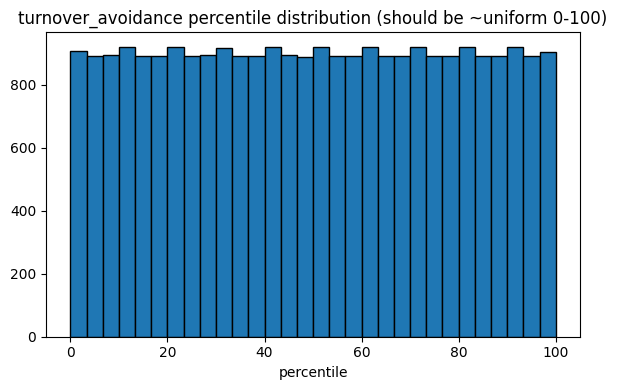

In [4]:
# Cell 3 — Shrinkage + percentiles
shrunk_df = pp.shrink_skills(player_df)
pctile_df = pp.skill_percentiles(shrunk_df)

print('Shrinkage spot-check — first 5 players, shooting_3p:')
spot = pctile_df[['player_id', 'season', 'raw_shooting_3p', 'prior_shooting_3p', 'skill_shooting_3p', '_weight']].head()
print(spot.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pctile_df['pctile_turnover_avoidance'], bins=30, edgecolor='black')
ax.set_title('turnover_avoidance percentile distribution (should be ~uniform 0-100)')
ax.set_xlabel('percentile')
plt.tight_layout()
plt.show()


## 4. Phase 0 — Value-Translation Model (Ridge vs. Hoop Explorer RAPM)

Regresses shrunk skills + position dummies on `off_adj_rapm`/`def_adj_rapm`.
These remain the primary training targets. `off_adj_rapm_prod`/`adj_rapm_prod_margin`
are also now ingested and used as a robustness check (not a retrain target) in Cell 5 —
see plan doc §5/§8 for the full corrected Hoop Explorer field inventory.


off_resid_std=1.584  def_resid_std=1.514

Ridge coefficients (skill -> RAPM):
                       off_coef  def_coef
skill                                    
shooting_3p               5.680    -0.567
shooting_2p_finishing     9.755    -2.139
free_throw_touch          6.405    -0.986
shot_creation_usage      -0.034     0.082
passing_creation          0.174    -0.053
turnover_avoidance       -0.273     0.040
offensive_rebounding      0.343    -0.063
defensive_rebounding      0.008    -0.052
steal_disruption         -0.037    -0.633
block_rim_protection      0.013    -0.208


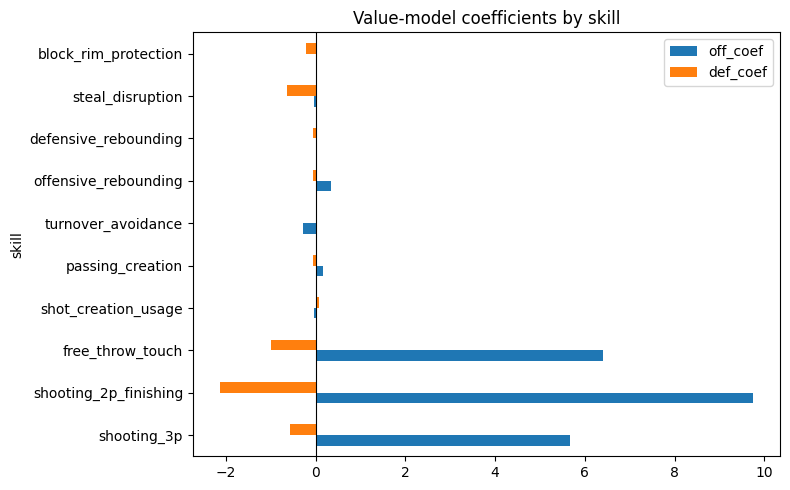

In [5]:
# Cell 4 — Fit value models + diagnostics
off_model, off_resid_std = pp.fit_value_model(pctile_df, 'off_adj_rapm')
def_model, def_resid_std = pp.fit_value_model(pctile_df, 'def_adj_rapm')
print(f'off_resid_std={off_resid_std:.3f}  def_resid_std={def_resid_std:.3f}')

coef_df = pd.DataFrame({
    'skill': SKILLS,
    'off_coef': off_model.coef_[:len(SKILLS)],
    'def_coef': def_model.coef_[:len(SKILLS)],
}).set_index('skill')
print('\nRidge coefficients (skill -> RAPM):')
print(coef_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
coef_df.plot.barh(ax=ax)
ax.set_title('Value-model coefficients by skill')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 5. Phase 0 — Projection + Spot Check

Applies the fitted value models to **every** player with season stats, not
just the Hoop-Explorer-matched training subset — that's what makes this a
projection rather than a label lookup.


In [6]:
# Cell 5 — Project value + spot check top players
projected_df = pp.project_value(pctile_df, off_model, def_model, off_resid_std, def_resid_std)

with engine.connect() as conn:
    names = pd.read_sql(text('SELECT id AS player_id, full_name FROM players'), conn)
top10 = (
    projected_df[projected_df['season'] == CURRENT_SEASON]
    .merge(names, on='player_id', how='left')
    .sort_values('value_per_100', ascending=False)
    .head(10)[['full_name', 'value_per_100', 'value_ci_lower', 'value_ci_upper']]
)
print(f'Top 10 projected value_per_100, season {CURRENT_SEASON}:')
print(top10.round(2).to_string(index=False))

# Robustness check (plan doc section 5/8): off_adj_rapm_prod / adj_rapm_prod_margin mix
# per-possession impact with playing-time share, so they are not retraining
# targets, but the projection should still track them directionally.
prod_check = projected_df[['off_value_per_100', 'off_adj_rapm_prod']].dropna()
prod_corr = prod_check['off_value_per_100'].corr(prod_check['off_adj_rapm_prod'])
print('Robustness check: off_value_per_100 vs off_adj_rapm_prod corr=' + format(prod_corr, '.3f') + ' (n=' + format(len(prod_check), ',') + ')')
margin_check = projected_df[['value_per_100', 'adj_rapm_prod_margin']].dropna()
margin_corr = margin_check['value_per_100'].corr(margin_check['adj_rapm_prod_margin'])
print('Robustness check: value_per_100 vs adj_rapm_prod_margin corr=' + format(margin_corr, '.3f') + ' (n=' + format(len(margin_check), ',') + ')')


Top 10 projected value_per_100, season 2026:
        full_name  value_per_100  value_ci_lower  value_ci_upper
 Jeremy Fears Jr.           4.65            1.84            7.46
     Malique Ewin           4.64            1.84            7.45
   Bruce Thornton           4.42            1.61            7.23
 Darius Acuff Jr.           4.34            1.54            7.15
       Tobe Awaka           4.33            1.52            7.14
 Ryan Prather Jr.           4.28            1.47            7.09
Trey Kaufman-Renn           4.25            1.45            7.06
    Joseph Tugler           4.23            1.43            7.04
      Oscar Cluff           4.17            1.36            6.98
  Nick Martinelli           4.00            1.20            6.81
Robustness check: off_value_per_100 vs off_adj_rapm_prod corr=0.643 (n=16,178)
Robustness check: value_per_100 vs adj_rapm_prod_margin corr=0.433 (n=16,178)


## 6. Phase 0 — Write to `player_projections`

Neutral-mode rows only (`school_id` NULL). Upserts via the partial unique
index on `(player_id, season, model_version) WHERE school_id IS NULL` — safe
to rerun. Same write path `scripts/run_player_projection.py` uses.


In [7]:
# Cell 6 — Write neutral projections
records = pp.build_neutral_records(projected_df)
upserted = pp.upsert_neutral_projections(engine, records)
print(f'Upserted {upserted:,} rows into player_projections (neutral mode)')


Upserted 27,047 rows into player_projections (neutral mode)


## 7. Phase 0 — MLflow Tracking


In [8]:
# Cell 7 — MLflow tracking (mirrors scheme_fit_scorer.ipynb / gap_matching.ipynb)
import mlflow
import mlflow.pyfunc
from portalpoint.modeling.mlflow_helpers import setup_mlflow, maybe_promote

values = np.array([r[4] for r in records], dtype=np.float64)
mean_value, std_value = float(values.mean()), float(values.std())
total_resid_std = float(np.sqrt(off_resid_std**2 + def_resid_std**2))

class PlayerProjectionPyfunc(mlflow.pyfunc.PythonModel):
    def __init__(self, off_model, def_model):
        self.off_model = off_model
        self.def_model = def_model

    def predict(self, context, model_input):
        X = pp.build_design_matrix(model_input)
        off = self.off_model.predict(X)
        defn = self.def_model.predict(X)
        return [{'value_per_100': float(o + d)} for o, d in zip(off, defn)]

client = setup_mlflow('player-projection')
with mlflow.start_run(run_name=f'player-projection-s{CURRENT_SEASON}-notebook') as run:
    mlflow.log_params({
        'seasons': ','.join(str(s) for s in SEASONS_IN_DATA),
        'model_version': MODEL_VERSION_PHASE0,
        'min_games': MIN_GAMES,
        'source': 'notebook',
    })
    mlflow.log_metrics({
        'mean_value_per_100': mean_value,
        'std_value_per_100': std_value,
        'off_resid_std': off_resid_std,
        'def_resid_std': def_resid_std,
        'total_resid_std': total_resid_std,
        'n_records_written': float(len(records)),
    })
    mlflow.pyfunc.log_model(artifact_path='player_projection_model', python_model=PlayerProjectionPyfunc(off_model, def_model))
    run_id = run.info.run_id

result = maybe_promote(client, 'player-projection', run_id, 'player_projection_model',
                        metric_name='total_resid_std', new_value=total_resid_std, higher_is_better=False)
print(f'Run ID: {run_id}')
print(f'Registry: {result}')


c:\Users\shant\Desktop\MIDS\MIDS210-Capstone\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


2026/06/23 15:02:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/23 15:02:05 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/06/23 15:02:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Registered model 'player-projection' already exists. Creating a new version of this model...


2026/06/23 15:02:52 WARNING mlflow.tracking._model_registry.fluent: Run with id 42366bc76451405fad62a4fad1c079d0 has no artifacts at artifact path 'player_projection_model', registering model based on models:/m-9c4694d0f2444140a0ad6748803e4b06 instead


Created version '6' of model 'player-projection'.


Run ID: 42366bc76451405fad62a4fad1c079d0
Registry: staging — player-projection v6 → Staging (Δ=+0.2%)


## 8. Phase 1 — Single-Season Game-Level State-Space (Validation)

Fits a scalar local-level Kalman filter/smoother per skill on
`hoopr_player_game_logs` for `GAME_LOG_SEASON` only. Cross-season `rho` and
the class-year development curve are **not** fit here — that's Phase 2, now
data-unblocked (Cell 1) but not attempted in this notebook. This stage does
not write to `player_projections` — it's a calibration check before Phase 2,
per plan doc §15.


In [9]:
# Cell 8 — Load game logs + build observations
GAME_LOG_SQL = '''
SELECT
    player_id, game_date, minutes,
    field_goals_made, field_goals_attempted,
    three_point_field_goals_made, three_point_field_goals_attempted,
    free_throws_made, free_throws_attempted,
    offensive_rebounds, defensive_rebounds,
    assists, steals, blocks, turnovers
FROM hoopr_player_game_logs
WHERE season = :season AND player_id IS NOT NULL
'''
with engine.connect() as conn:
    game_logs = pd.read_sql(text(GAME_LOG_SQL), conn, params={'season': GAME_LOG_SEASON})
print(f'Loaded {len(game_logs):,} player-game rows for season {GAME_LOG_SEASON}')

obs_df = ppk.build_game_observations(game_logs)
print(f'Players with at least one observed game: {obs_df["player_id"].nunique():,}')


Loaded 153,064 player-game rows for season 2026


Players with at least one observed game: 4,863


## 9. Phase 1 — Pooled-MLE Q Fit Per Skill

`Q` (process variance) is fit once per skill via pooled MLE across every
player's game sequence — fitting a separate Q per player would be unstable
on panels this short. Bounds are `ppk.Q_BOUNDS` (widened to `[1e-6, 100.0]` 2026-06-23 to match the corrected
`R_t` scale — see §13); a fit landing exactly at either bound is a red flag, not a valid result.


In [10]:
# Cell 9 — Fit Q per skill
fitted_q, kalman_df = ppk.smooth_all_skills(obs_df)
kalman_df['season'] = GAME_LOG_SEASON

q_lo, q_hi = ppk.Q_BOUNDS
q_table = pd.DataFrame([
    {'skill': skill, 'fitted_Q': q, 'at_bound': np.isclose(q, q_lo, rtol=1e-3) or np.isclose(q, q_hi, rtol=1e-3)}
    for skill, q in fitted_q.items()
])
print(q_table.to_string(index=False))
print('\nAT-BOUND skills indicate R_t mis-scaling, not real model behavior — see Cell 10.')


                skill  fitted_Q  at_bound
          shooting_3p  0.000012     False
shooting_2p_finishing  0.000028     False
     free_throw_touch  0.000019     False
  shot_creation_usage  0.119006     False
     passing_creation  0.032335     False
   turnover_avoidance  0.004017     False
 offensive_rebounding  0.010669     False
 defensive_rebounding  0.031925     False
     steal_disruption  0.007255     False
 block_rim_protection  0.002832     False

AT-BOUND skills indicate R_t mis-scaling, not real model behavior — see Cell 10.


## 10. Phase 1 — Q Likelihood Curves (Diagnosing the Bound Issue)

Plots the pooled negative log-likelihood across a grid of `Q` values for one
well-behaved skill (`shooting_3p`, Q fit lands away from either bound) and one
problem skill (`turnover_avoidance`, Q saturates at the upper bound). A curve
that's still falling at the right edge of the search range confirms the
optimizer is genuinely pinned at the bound, not just landing near it by
coincidence.


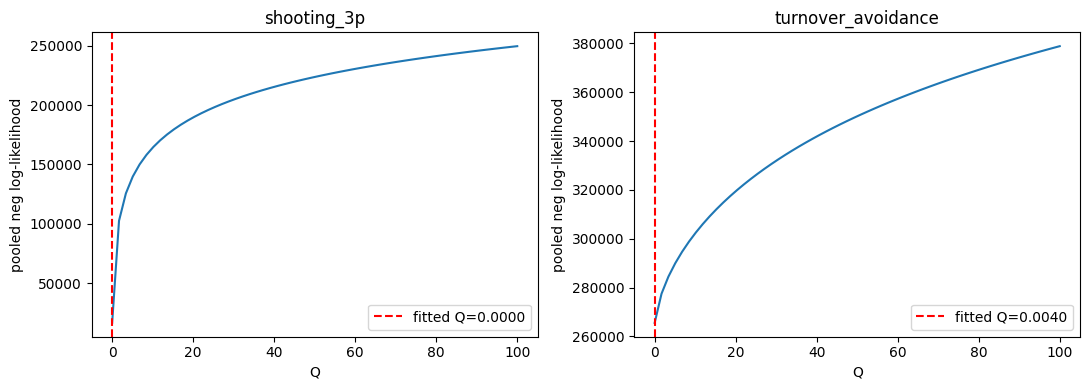

In [11]:
# Cell 10 — Q likelihood curves
q_grid = np.linspace(*ppk.Q_BOUNDS, 60)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    sequences = list(ppk.build_player_sequences(obs_df, skill).values())
    nll = [ppk.pooled_neg_log_likelihood(q, sequences) for q in q_grid]
    ax.plot(q_grid, nll)
    ax.axvline(fitted_q[skill], color='red', linestyle='--', label=f'fitted Q={fitted_q[skill]:.4f}')
    ax.set_title(skill)
    ax.set_xlabel('Q')
    ax.set_ylabel('pooled neg log-likelihood')
    ax.legend()
plt.tight_layout()
plt.show()


## 11. Phase 1 — Smoothed Trajectories (Sample Player)

Filtered vs. smoothed state over the season for one high-minutes player,
for the same two skills — visualizes what the at-bound Q actually does to
the state estimate (turnover_avoidance should look like it's just tracking
raw noisy observations with almost no smoothing).


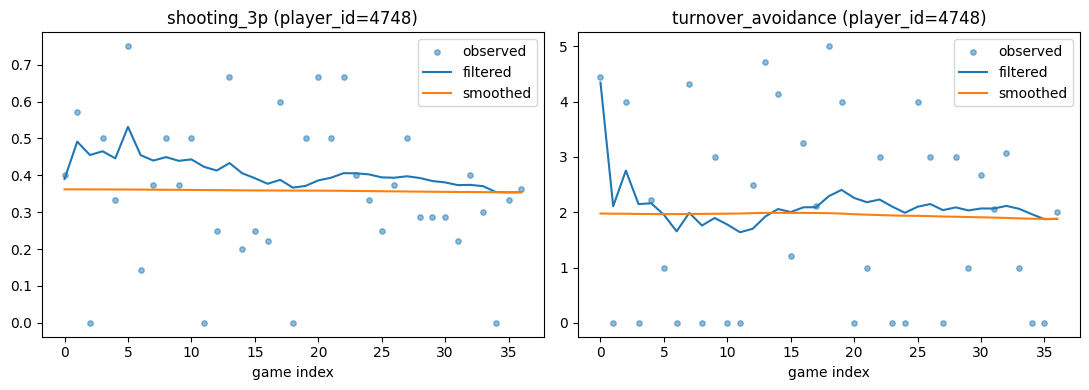

In [12]:
# Cell 11 — Smoothed trajectory plot for a sample high-minutes player
sample_player_id = (
    obs_df.groupby('player_id')['minutes'].sum().sort_values(ascending=False).index[0]
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    sequences = ppk.build_player_sequences(obs_df, skill)
    y, R, mask, prior_mean, prior_var = sequences[sample_player_id]
    q_value = fitted_q[skill]
    a, P, _, _ = ppk.kalman_filter_series(y, R, q_value, mask, prior_mean, prior_var)
    a_s, _ = ppk.kalman_smoother_series(a, P, q_value)

    game_idx = np.arange(len(y))
    ax.scatter(game_idx[mask], y[mask], s=15, alpha=0.5, label='observed')
    ax.plot(game_idx, a, label='filtered')
    ax.plot(game_idx, a_s, label='smoothed')
    ax.set_title(f'{skill} (player_id={sample_player_id})')
    ax.set_xlabel('game index')
    ax.legend()
plt.tight_layout()
plt.show()


## 12. Phase 1 — Calibration Check vs. Phase 0

Two independent estimators (single-season Kalman vs. multi-season shrinkage)
agreeing is the calibration signal called for in plan doc §15. Recomputes
Phase 0 on the `GAME_LOG_SEASON`-only subset for a fair comparison, since the
full Phase 0 run above pools 6 seasons.


                skill    n  corr
          shooting_3p 4506 0.595
shooting_2p_finishing 4506 0.590
     free_throw_touch 4506 0.780
  shot_creation_usage 4506 0.773
     passing_creation 4506 0.813
   turnover_avoidance 4506 0.500
 offensive_rebounding 4506 0.777
 defensive_rebounding 4506 0.768
     steal_disruption 4506 0.715
 block_rim_protection 4506 0.802


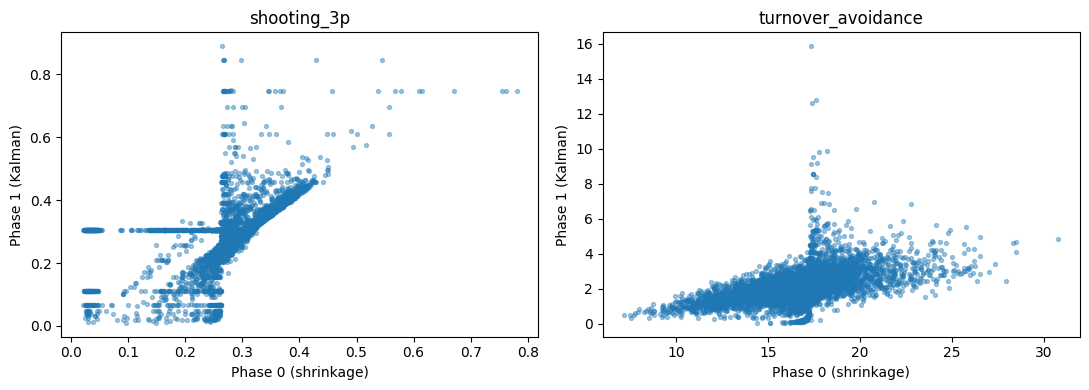

In [13]:
# Cell 12 — Calibration check
season_only_df = player_df[player_df['season'] == GAME_LOG_SEASON].copy()
phase0_season_df = pp.shrink_skills(season_only_df)

merged = kalman_df.merge(phase0_season_df, on=['player_id', 'season'], how='inner', suffixes=('_kalman', '_phase0'))

corr_rows = []
for skill in ppk.SKILLS:
    k_col, p_col = f'skill_{skill}_kalman', f'skill_{skill}_phase0'
    valid = merged[[k_col, p_col]].dropna()
    corr_rows.append({'skill': skill, 'n': len(valid), 'corr': valid[k_col].corr(valid[p_col]) if len(valid) > 10 else np.nan})
corr_df = pd.DataFrame(corr_rows)
print(corr_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, skill in zip(axes, ['shooting_3p', 'turnover_avoidance']):
    ax.scatter(merged[f'skill_{skill}_phase0'], merged[f'skill_{skill}_kalman'], s=8, alpha=0.4)
    ax.set_xlabel('Phase 0 (shrinkage)')
    ax.set_ylabel('Phase 1 (Kalman)')
    ax.set_title(skill)
plt.tight_layout()
plt.show()


## 13. Known Issues / Next Steps

- **[FIXED 2026-06-23] Count-rate skills' `R_t` was mis-scaled.** Root cause: `R_t = 1/weight` implicitly assumed a numerator of 1.0 — correct shape for Bernoulli shooting rates (numerator ~ p(1-p), roughly constant ~0.2-0.25) but wrong for Poisson count-rates, where true variance scales with the rate itself (derived: Var(y) = mean_rate * 40 / minutes). Fixed in `player_projection_kalman.py`'s `_r_numerator()`; `Q_BOUNDS` widened from `(1e-6, 2.0)` to `(1e-6, 100.0)` to match the corrected R_t scale. Result: **zero skills at-bound** (Cell 9), and Phase 0/Phase 1 correlation jumped sharply for every count-rate skill (usage 0.39→0.77, passing 0.37→0.81, turnover 0.15→0.50, off/def rebounding 0.29/0.27→0.78/0.77, steal 0.17→0.72, block 0.39→0.80 — Cell 12).
- **Shooting skills still behave correctly post-fix.** Q stays near-zero (now ~1e-5, was ~5e-6) — within-season shooting touch still doesn't drift much beyond binomial noise, consistent with basketball domain knowledge. Their Phase 0 correlation dipped slightly (0.61→0.60, 0.68→0.59) — minor, expected from the numerator changing from flat 1.0 to p(1-p), not a regression.
- **Phase 2 is data-unblocked** (Cell 1 — full 2020-2026 game-log backfill complete) **and Phase 1 is now calibrated** — both blockers from the original known-issues list are resolved. Phase 2 (block covariance, cross-season `rho`/dev-curve) is the next real step, not attempted in this notebook.
- See `docs/models/player_projection_state_space_plan.md` §15 for the full phase staging and §17 for the implementation plan this notebook is part of.


- **[INVESTIGATED, NOT A BUG — 2026-06-23] def_adj_rapm vs. box-score defense.** block_rim_protection/steal_disruption have negative Ridge coefficients against def_adj_rapm (Cell 4). Checked three confounds, all ruled out: (1) competition tier (qcut quartiles of team adj_em) — negative correlation holds at similar magnitude in all 4 tiers, -0.15 to -0.24; (2) position (HE pos_class) — holds within every single position group, -0.13 to -0.30, even though mean def_adj_rapm itself is strongly position-biased (C=-0.51 vs WG=+0.21); (3) sample size/minutes — holds even restricted to min_pct>=70 (heavy-minutes players only), -0.15 to -0.23. **Conclusion: real, robust property of this RAPM label, not a pipeline bug or confound** — consistent with a known tension in basketball analytics (gambling for blocks/steals trades off court positioning; rim-protector minutes are hard for RAPM-style on/off models to cleanly isolate from foul-trouble/matchup substitution patterns). The Ridge model is correctly learning this signal, not introducing an artifact — no fix applied. Worth a product-facing caveat eventually (value_per_100 may under-rate high-block/steal defenders relative to box-score intuition), not a modeling fix.